<a href="https://colab.research.google.com/github/Musharab1/Next-Word-Prediction/blob/main/Next_word_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Next-Word Predictor**

## **Objective**
Train a multi-layer neural network to approximate the **next-word probability** distribution for a sequence of text, given the preceding N words as context.

**Submitted to:**

    Dr. Umar Rashid
    
**Submitted by:**

    Musharab Sabeen(2022-EE-251)
    Ahsan bin Asif(2022-EE-274)

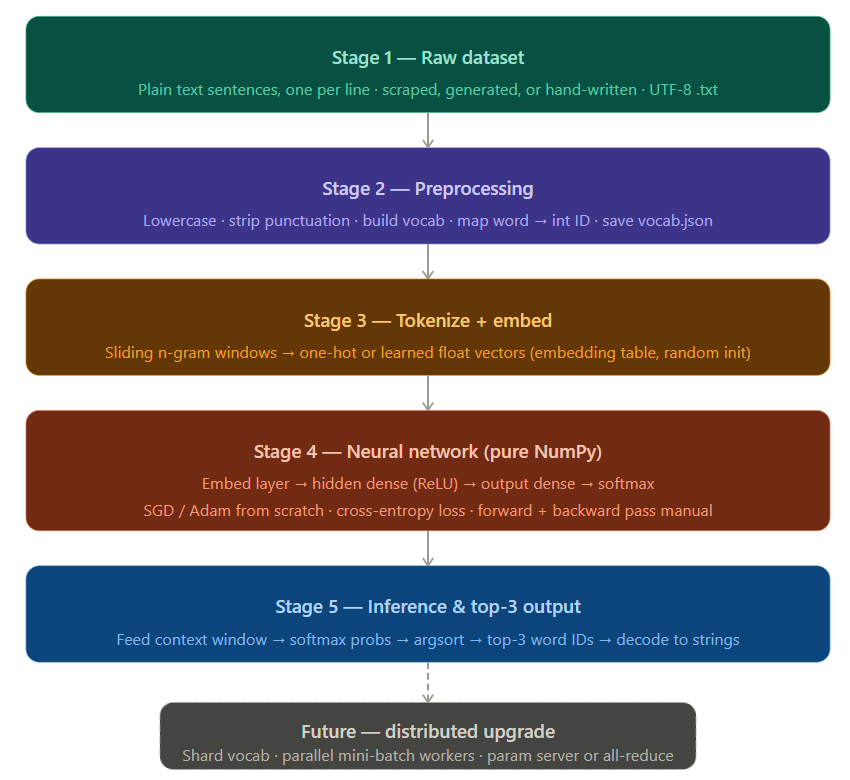

# **Connection Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_FILE='/content/drive/MyDrive/Next_word_predictor/sentences.txt'
EMBEDDINGS_FILE='/content/drive/MyDrive/Next_word_predictor/embeddings.npy'
VOCAB_FILE='/content/drive/MyDrive/Next_word_predictor/vocab.pkl'
PARAMETERS_FILE='/content/drive/MyDrive/Next_word_predictor/model_parameters.pkl'
EMBED_DIM=128
N=3 # Number of previous words

# **Tokenizing & Preprocessing**

In [ ]:
import re                 # regular expression module for text processing

def tokenize(text):
    text = text.lower()                   # Convert to lowercase for consistent processing
    text = re.sub(r"[^a-z\s]", "", text)  # keep lowercase letters or spaces only
    return text.split()                   # Split on spaces to a list of words (tokens)


# Open the 'sentences.txt' file, read its content, convert to lowercase, and split into sentences
sentences = open(DATASET_FILE).read().lower().split('\n')
all_tokens = []
# Iterate through each sentence and tokenize it, then extend the all_tokens list
for sentence in sentences:
    all_tokens.extend(tokenize(sentence))

## **Make Vocabulary**

In [ ]:
from collections import Counter    # Import the Counter class from the collections module to count word frequencies
freq = Counter(all_tokens)                  # Count the frequency of each token in the all_tokens list <dict>

# Build the vocabulary: assign a unique ID to each word that appears 3 or more times
vocab = {}
idx = 0
for word, count in freq.items():
    if count >= 2:
        vocab[word] = idx
        idx += 1

# Add a special token for unknown words ('<UNK>') and assign it the next available ID
vocab["<UNK>"] = len(vocab)

word_to_id = vocab                                      # Create a mapping from word to its corresponding ID

id_to_word = {}
for word, idx in vocab.items():
    id_to_word[idx] = word

#print (freq.items())

# **Creating Embeddings**
64bits - Creates random embeddings for all vocabulary.

In [ ]:
import numpy as np

vocab_size = len(vocab)

# Xavier init (better — keeps variance stable as embed_dim grows)
scale = np.sqrt(1.0 / EMBED_DIM)
embed_table = np.random.uniform(-scale, scale, (vocab_size, EMBED_DIM)).astype(np.float32)
#print ( embed_table)

# **Creating Training Examples**
We will create context-target pairs from our tokenized text. For each word, we'll use a context window of `N=3` preceding words to predict the current word.



In [ ]:
# Convert all tokens to their IDs
all_word_ids = []

for word in all_tokens:
    if word in word_to_id:
        all_word_ids.append(word_to_id[word])
    else:
        all_word_ids.append(word_to_id["<UNK>"])

context_ids_all = [] # List of N-word contexts (e.g., [[id1, id2, id3], [id2, id3, id4], ...])
Y_ids_all = []       # List of target word IDs (e.g., [id4, id5, ...])

for i in range(N, len(all_word_ids)):
    context = all_word_ids[i-N : i]
    target = all_word_ids[i]

    context_ids_all.append(context)
    Y_ids_all.append(target)

print(f"Generated {len(context_ids_all)} training examples.")
print(f"First context: {context_ids_all[0]}, First target: {Y_ids_all[0]}")
print(f"Words: {[id_to_word[id] for id in context_ids_all[0]]} -> {id_to_word[Y_ids_all[0]]}")

Generated 21817 training examples.
First context: [0, 1, 2004], First target: 2
Words: ['the', 'quick', '<UNK>'] -> fox


# **All the required fuctions for NN**

**Neutal Network Archetecture:**


```
Input:   [w1_embed ; w2_embed ; w3_embed]  → shape (N*embed_dim,) 3*128
Hidden:  Dense(256) + ReLU
Output:  Dense(vocab_size) + Softmax ~1000
Loss:    Cross-entropy```



In [ ]:
import numpy as np
from collections import defaultdict

# ── ACTIVATIONS ─────────────────────────────────────────────────────────────

def leaky_relu(Z, alpha=0.01):
    return np.where(Z > 0, Z, alpha * Z)

def leaky_relu_backward(dA, Z, alpha=0.01):
    dZ = np.ones_like(Z)
    dZ[Z < 0] = alpha
    return dA * dZ

def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    e = np.exp(Z)
    return e / np.sum(e, axis=0, keepdims=True)


# ── LAYER SIZES ──────────────────────────────────────────────────────────────

def layer_sizes(N, embed_dim, hidden_size, vocab_size):
    n_x = N * embed_dim     # 3 * 128 = 384
    n_h1 = 256              # first hidden layer
    n_h2 = 128              # second hidden layer
    n_y = vocab_size
    return n_x, n_h1, n_h2, n_y


# ── INITIALIZE PARAMETERS ────────────────────────────────────────────────────

def initialize_parameters(n_x, n_h1, n_h2, n_y):
    np.random.seed(2)

    W1 = np.random.randn(n_h1, n_x)  * np.sqrt(2.0 / n_x)   # (256, 384)
    b1 = np.zeros((n_h1, 1))                                  # (256, 1)
    W2 = np.random.randn(n_h2, n_h1) * np.sqrt(2.0 / n_h1)  # (128, 256)
    b2 = np.zeros((n_h2, 1))                                  # (128, 1)
    W3 = np.random.randn(n_y, n_h2)  * np.sqrt(2.0 / n_h2)  # (vocab_size, 128)
    b3 = np.zeros((n_y, 1))                                   # (vocab_size, 1)

    assert W1.shape == (n_h1, n_x)
    assert W2.shape == (n_h2, n_h1)
    assert W3.shape == (n_y, n_h2)

    parameters = {"W1": W1, "b1": b1,
                  "W2": W2, "b2": b2,
                  "W3": W3, "b3": b3}
    return parameters


# ── FORWARD PROPAGATION ──────────────────────────────────────────────────────

def forward_propagation(X, parameters):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    W3 = parameters["W3"]
    b3 = parameters["b3"]

    Z1 = np.dot(W1, X) + b1       # (256, m)
    A1 = leaky_relu(Z1)            # (256, m)
    Z2 = np.dot(W2, A1) + b2      # (128, m)
    A2 = leaky_relu(Z2)            # (128, m)
    Z3 = np.dot(W3, A2) + b3      # (vocab_size, m)
    A3 = softmax(Z3)               # (vocab_size, m)

    assert A3.shape == (W3.shape[0], X.shape[1])

    cache = {"Z1": Z1, "A1": A1,
             "Z2": Z2, "A2": A2,
             "Z3": Z3, "A3": A3}
    return A3, cache


# ── COMPUTE COST ─────────────────────────────────────────────────────────────

def compute_cost(A3, Y_ids):
    m = A3.shape[1]
    correct_probs = A3[Y_ids, np.arange(m)]
    cost = -np.sum(np.log(correct_probs + 1e-9)) / m
    return float(np.squeeze(cost))


# ── BACKWARD PROPAGATION ─────────────────────────────────────────────────────

def backward_propagation(parameters, cache, X, Y_ids):
    m  = X.shape[1]
    W2 = parameters["W2"]
    W3 = parameters["W3"]
    A1 = cache["A1"]
    Z1 = cache["Z1"]
    A2 = cache["A2"]
    Z2 = cache["Z2"]
    A3 = cache["A3"]

    # ── output layer ──────────────────────────────────────
    dZ3 = A3.copy()                           # (vocab_size, m)
    dZ3[Y_ids, np.arange(m)] -= 1
    dZ3 /= m

    dW3 = np.dot(dZ3, A2.T)                  # (vocab_size, 128)
    db3 = np.sum(dZ3, axis=1, keepdims=True) # (vocab_size, 1)

    # ── second hidden layer ───────────────────────────────
    dA2 = np.dot(W3.T, dZ3)                  # (128, m)
    dZ2 = leaky_relu_backward(dA2, Z2)        # (128, m)

    dW2 = np.dot(dZ2, A1.T)                  # (128, 256)
    db2 = np.sum(dZ2, axis=1, keepdims=True) # (128, 1)

    # ── first hidden layer ────────────────────────────────
    dA1 = np.dot(W2.T, dZ2)                  # (256, m)
    dZ1 = leaky_relu_backward(dA1, Z1)        # (256, m)

    dW1 = np.dot(dZ1, X.T)                   # (256, 384)
    db1 = np.sum(dZ1, axis=1, keepdims=True) # (256, 1)

    # ── gradient w.r.t input (flows to embeddings) ────────
    dX = np.dot(parameters["W1"].T, dZ1)     # (384, m)

    grads = {"dW1": dW1, "db1": db1,
             "dW2": dW2, "db2": db2,
             "dW3": dW3, "db3": db3,
             "dX":  dX}
    return grads


# ── UPDATE PARAMETERS ────────────────────────────────────────────────────────

def update_parameters(parameters, grads, learning_rate=0.01):
    parameters["W1"] -= learning_rate * grads["dW1"]
    parameters["b1"] -= learning_rate * grads["db1"]
    parameters["W2"] -= learning_rate * grads["dW2"]
    parameters["b2"] -= learning_rate * grads["db2"]
    parameters["W3"] -= learning_rate * grads["dW3"]
    parameters["b3"] -= learning_rate * grads["db3"]
    return parameters


# ── UPDATE EMBEDDING TABLE ───────────────────────────────────────────────────

def update_embeddings(embed_table, dX, context_ids_batch, embed_dim, lr):
    N = len(context_ids_batch[0])
    grad_accum = defaultdict(lambda: np.zeros(embed_dim))

    for sample_idx, context_ids in enumerate(context_ids_batch):
        dx_sample = dX[:, sample_idx]                    # (N*embed_dim,)
        for pos, word_id in enumerate(context_ids):
            grad = dx_sample[pos*embed_dim : (pos+1)*embed_dim]
            grad_accum[word_id] += grad

    for word_id, grad in grad_accum.items():
        embed_table[word_id] -= lr * grad


# ── FULL TRAINING LOOP ───────────────────────────────────────────────────────

def nn_model(context_ids_all, Y_ids_all, embed_table,
             embed_dim, vocab_size,n_h1=256, n_h2=128,
             num_iterations=10000, batch_size=64,
             learning_rate=0.01, print_cost=False):

    N    = len(context_ids_all[0])   # context window size e.g. 3
    n_x  = N * embed_dim             # 3 * 128 = 384
    n_y  = vocab_size

    parameters = initialize_parameters(n_x, n_h1, n_h2, n_y)

    m_total = len(Y_ids_all)

    for i in range(num_iterations):

        # ── sample a random mini-batch ─────────────────────
        idx       = np.random.choice(m_total, batch_size, replace=False)
        batch_ctx = [context_ids_all[j] for j in idx]
        batch_y   = np.array([Y_ids_all[j] for j in idx])

        # ── build X by looking up embeddings ───────────────
        X = np.column_stack([
            np.concatenate([embed_table[w] for w in ctx])
            for ctx in batch_ctx
        ])                                   # (384, batch_size)

        # ── forward ────────────────────────────────────────
        A3, cache = forward_propagation(X, parameters)

        # ── cost ───────────────────────────────────────────
        cost = compute_cost(A3, batch_y)

        # ── backward ───────────────────────────────────────
        grads = backward_propagation(parameters, cache, X, batch_y)

        # ── update network weights ─────────────────────────
        parameters = update_parameters(parameters, grads, learning_rate)

        # ── update embedding table ─────────────────────────
        update_embeddings(embed_table, grads["dX"],
                          batch_ctx, embed_dim, learning_rate)

        if print_cost and i % 5000 == 0:
            print(f"Cost after iteration {i}: {cost:.4f}")

    return parameters


# ── PREDICT ──────────────────────────────────────────────────────────────────

def predict(parameters, embed_table, context_ids, inv_vocab, top_k=3):
    x  = np.concatenate([embed_table[i] for i in context_ids])  # (384,)
    X  = x.reshape(-1, 1)                                        # (384, 1)

    A3, _ = forward_propagation(X, parameters)   # (vocab_size, 1)
    probs  = A3[:, 0]                             # (vocab_size,)

    top_ids   = np.argsort(probs)[-top_k:][::-1]
    top_probs = probs[top_ids]

    return [(inv_vocab[i], round(float(p), 4)) for i, p in zip(top_ids, top_probs)]

# **Load the model from the drive otherwise train a new model and save in the drive**

In [ ]:
import numpy as np
import pickle
try:
  # Load the embedding table
  embed_table = np.load(EMBEDDINGS_FILE)
  print("Embedding table loaded successfully from drive.")

  # Load the model parameters
  with open(PARAMETERS_FILE, 'rb') as f:
      parameters = pickle.load(f)
  print("Model parameters loaded successfully from drive.")

  # Load vocabulary
  with open(VOCAB_FILE, 'rb') as f:
      vocab = pickle.load(f)

  word_to_id = vocab
  id_to_word = {idx: word for word, idx in vocab.items()}
  print("Vocabulary loaded successfully from drive.")
  print(f"Loaded vocabulary size: {len(vocab)}")
  print(f"Loaded embedding table shape: {embed_table.shape}")

except:

  parameters = nn_model(
    context_ids_all=context_ids_all,
    Y_ids_all=Y_ids_all,
    embed_table=embed_table,
    n_h1=256,n_h2=128,
    embed_dim=EMBED_DIM,
    vocab_size=vocab_size,
    num_iterations=300000,
    batch_size=64,
    learning_rate=0.01,
    print_cost=True
  )
  print("\nModel training complete. Learned parameters stored in 'parameters'.")
  try:
    # Save the embedding table
    np.save(EMBEDDINGS_FILE, embed_table)
    print("Embedding table saved to drive 'embeddings.npy'")

    # Save the model parameters
    with open(PARAMETERS_FILE, 'wb') as f:
        pickle.dump(parameters, f)
    print("Model parameters saved to drive 'model_parameters.pkl'")

    # Save vocabulary
    with open(VOCAB_FILE, "wb") as f:
        pickle.dump(vocab, f)

    print("Vocabulary saved to drive 'vocab.pkl'")
  except:
    print("Error saving files to drive.")

Embedding table loaded successfully from drive.
Model parameters loaded successfully from drive.
Vocabulary loaded successfully from drive.
Loaded vocabulary size: 2005
Loaded embedding table shape: (2005, 128)


# **User Interface**

In [ ]:
!pip install gradio
!pip install rfc3987

# **Live Update of suggestions + Learning Button**


In [ ]:
def save_updated_model():
    np.save(EMBEDDINGS_FILE, embed_table)
    with open(PARAMETERS_FILE, 'wb') as f:
        pickle.dump(parameters, f)

def online_learn(new_sentence, parameters, embed_table,word_to_id, id_to_word,N=3, embed_dim=EMBED_DIM, lr=0.005, steps=30):
    """
    Given a new sentence typed by the user, extract context-target pairs
    and update the model weights at the moment (online learning).
    """
    tokens = tokenize(new_sentence)
    token_ids = []

    for word in tokens:
        if word in word_to_id:
            token_ids.append(word_to_id[word])
        else:
            token_ids.append(word_to_id["<UNK>"])

    # Extract context-target pairs from the new sentence
    new_contexts = []
    new_targets = []
    for i in range(N, len(token_ids)):
        new_contexts.append(token_ids[i - N : i])
        new_targets.append(token_ids[i])

    m = len(new_targets)

    for step in range(steps):
        # Build input matrix X from embeddings
        X = np.column_stack([
            np.concatenate([embed_table[w] for w in ctx])
            for ctx in new_contexts
        ])  # (N*embed_dim, m)

        Y_ids = np.array(new_targets)

        # Forward + backward + update (reuse your existing functions)
        A2, cache = forward_propagation(X, parameters)
        grads = backward_propagation(parameters, cache, X, Y_ids)
        parameters = update_parameters(parameters, grads, lr)
        update_embeddings(embed_table, grads["dX"], new_contexts, embed_dim, lr)

    return parameters  # embed_table updated in-place


def preprocess_text(text):
  tokens = tokenize(text)

  context_tokens = tokens[-N:]

  if len(context_tokens) < N:
      context_tokens = [word_to_id["<UNK>"]] * (N - len(context_tokens)) + context_tokens

  context_ids = [
      word_to_id.get(word, word_to_id["<UNK>"])
      for word in context_tokens
  ]
  return context_ids


def predict_next_words(text):
    top_k_display = 5 # Number of predictions to display
    context_ids = preprocess_text(text)

    # Call predict with the correct context_ids and a slightly larger top_k
    # to account for filtered out tokens
    top_predictions_raw = predict(parameters, embed_table, context_ids, id_to_word, top_k_display + 5)

    valid_predictions = []

    for word, prob in top_predictions_raw:
        # Skip invalid/special tokens
        if (word.strip() == "" or word in ["<UNK>", "<PAD>", "\n"]):
            continue
        valid_predictions.append((word, prob))

        # Keep only top_k_display valid predictions
        if len(valid_predictions) == top_k_display:
            break

    # Build output
    output = "## Top Predictions\n\n"

    for i, (word, prob) in enumerate(valid_predictions, start=1):
        output += (
            f"{i}. **{word}** "
            f"— Confidence: {prob * 100:.2f}%\n\n" # Multiply by 100 for display
        )

    return output

In [ ]:
import gradio as gr
import numpy as np

# ── CUSTOM CSS ───────────────────────────────────────────────────────────────

custom_css = """
body { font-family: 'Times New Roman'; }

.gradio-container { max-width: 900px !important; margin: auto; }

h1 { text-align: center; color: #4A90E2; }

/* Suggestion buttons row */
.suggestion-row {
    display: flex;
    gap: 10px;
    flex-wrap: wrap;
    margin-top: 8px;
}

.word-btn {
    background: none !important;
    color: white !important;
    border: none !important;
    border-radius: 20px !important;
    padding: 6px 16px !important;
    cursor: pointer !important;
    font-size: 14px !important;
    transition: background 0.2s;
}

.word-btn:hover {
    color: #357ABD !important;
}

/* Learn button */
.learn-btn {
    margin-top: 12px;
    background: #27AE60 !important;
    color: white !important;
    border-radius: 20px !important;
    padding: 8px 24px !important;
}

.learn-btn:hover { background: #1E8449 !important; }

/* Status message */
.status-box {
    margin-top: 8px;
    font-size: 13px;
    color: #555;
}
"""

# ── CORE LOGIC ───────────────────────────────────────────────────────────────

TOP_K = 5   # how many suggestions to show

def get_predictions(text):
    """Return top-K (word, prob) pairs for the current text."""
    context_ids = preprocess_text(text)
    raw = predict(parameters, embed_table, context_ids, id_to_word, TOP_K + 10)

    valid = []
    for word, prob in raw:
        if word.strip() == "" or word in ["<UNK>", "<PAD>", "\n"]:
            continue
        if prob < 0.01:
            continue
        valid.append((word, prob))
        if len(valid) == TOP_K:
            break
    return valid


def on_text_change(current_text):
    """
    Fires on every keystroke.
    Returns updated suggestion labels for the 5 buttons.
    """
    if not current_text.strip():
        # blank slate — clear all buttons
        return [""] * TOP_K

    preds = get_predictions(current_text)

    # Pad to TOP_K in case fewer valid words were found
    labels = [f"{w}  {p*100:.1f}%" for w, p in preds]
    while len(labels) < TOP_K:
        labels.append("")

    return labels


def append_word(current_text, word_with_prob):
    """
    Called when user clicks a suggestion button.
    Strips the probability suffix and appends the word to the textbox.
    Returns (new_text, new_button_labels).
    """
    if not word_with_prob.strip():
        # Empty button clicked — do nothing
        new_labels = on_text_change(current_text)
        return current_text, *new_labels

    # word_with_prob looks like "hello  72.3%"
    word = word_with_prob.split()[0]

    # Append with a space
    new_text = current_text.rstrip() + " " + word

    new_labels = on_text_change(new_text)
    return new_text, *new_labels


def learn_and_confirm(current_text):
    """
    Called when user clicks 'Learn from this sentence'.
    Runs online learning on the completed sentence.
    """
    if not current_text.strip():
        return "⚠️ Nothing to learn from — type a sentence first."

    tokens = tokenize(current_text)
    if len(tokens) < N + 1:
        return f"⚠️ Too short — need at least {N+1} words."

    online_learn(current_text, parameters, embed_table,word_to_id, id_to_word,N=N, embed_dim=EMBED_DIM, lr=0.005, steps=20)

    save_updated_model()   # persist to Drive

    return f"✅ Learned from: \"{current_text.strip()}\""


# ── UI ───────────────────────────────────────────────────────────────────────

with gr.Blocks(css=custom_css) as demo:

    gr.Markdown("# **Next Word Predictor**")
    gr.Markdown(
        "Type below — click a suggestion to append it. "
        "Hit **Learn** when your sentence is complete."
    )

    # ── main textbox ──────────────────────────────────────
    text_box = gr.Textbox(
        lines=4,
        placeholder="Start typing...",
        label="Your sentence",
        autofocus=True,
    )

    # ── suggestion buttons (one row) ──────────────────────
    gr.Markdown("**Suggestions:**")
    with gr.Row(elem_classes=["suggestion-row"]):
        btns = [
            gr.Button(value="", elem_classes=["word-btn"], size="sm")
            for _ in range(TOP_K)
        ]

    # ── learn button + status ─────────────────────────────
    with gr.Row():
        learn_btn = gr.Button(
            "⬇ Learn from this sentence",
            elem_classes=["learn-btn"],
            size="sm"
        )
    status_box = gr.Markdown(elem_classes=["status-box"])

    # ── EVENTS ────────────────────────────────────────────

    # 1. Typing → update suggestion button labels
    text_box.change(
        fn=on_text_change,
        inputs=text_box,
        outputs=btns,           # list of Button components
    )

    # 2. Clicking any suggestion button → append word + refresh buttons
    for btn in btns:
        btn.click(
            fn=append_word,
            inputs=[text_box, btn],
            outputs=[text_box, *btns],  # update textbox AND all buttons
        )

    # 3. Learn button → online learning
    learn_btn.click(
        fn=learn_and_confirm,
        inputs=text_box,
        outputs=status_box,
    )

demo.launch(share=True)

/tmp/ipykernel_3480/4083367061.py:137: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f5e07ef45ed84a5652.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
